In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Load data
df = pd.read_csv("../data/processed/final_features.csv")

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

X = df.drop(columns=['Converted'])
y = df['Converted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

print("✅ Model ready for SHAP analysis")


✅ Model ready for SHAP analysis


In [2]:
# Convert scaled test data back to DataFrame for readable feature names
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

explainer = shap.LinearExplainer(log_reg, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

print("✅ SHAP values calculated")
print("Shape:", shap_values.shape)

Background dataset has 7392 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=7392 when initializing the masker.


✅ SHAP values calculated
Shape: (1848, 30)


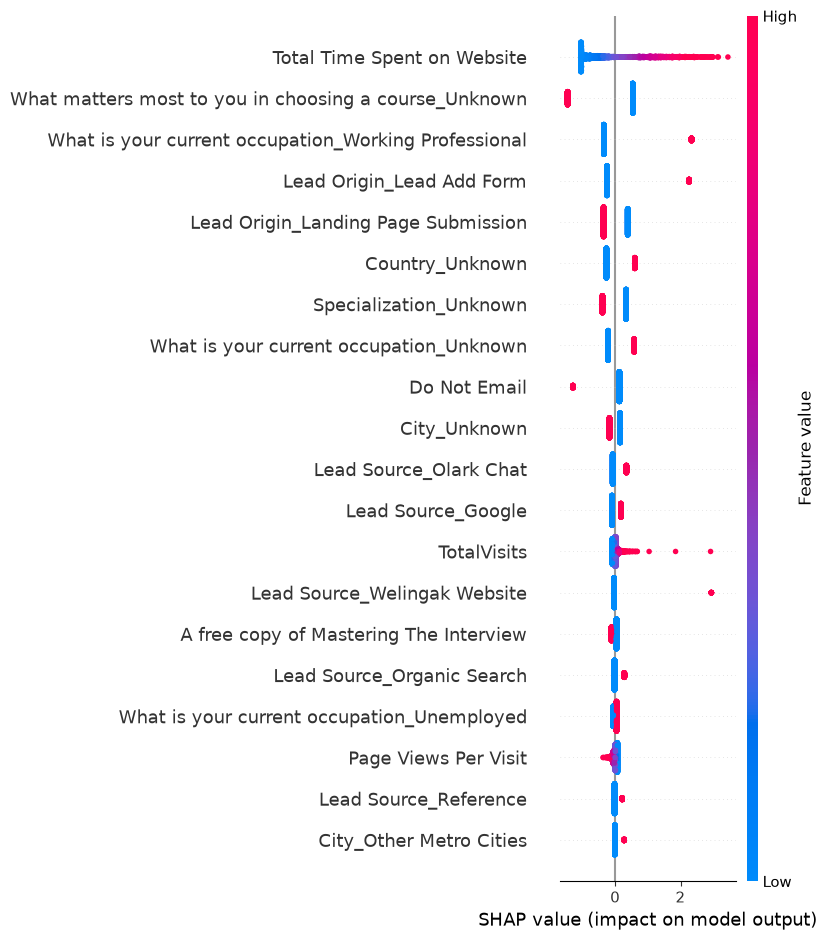

In [3]:
shap.summary_plot(shap_values, X_test_scaled_df, show=True)

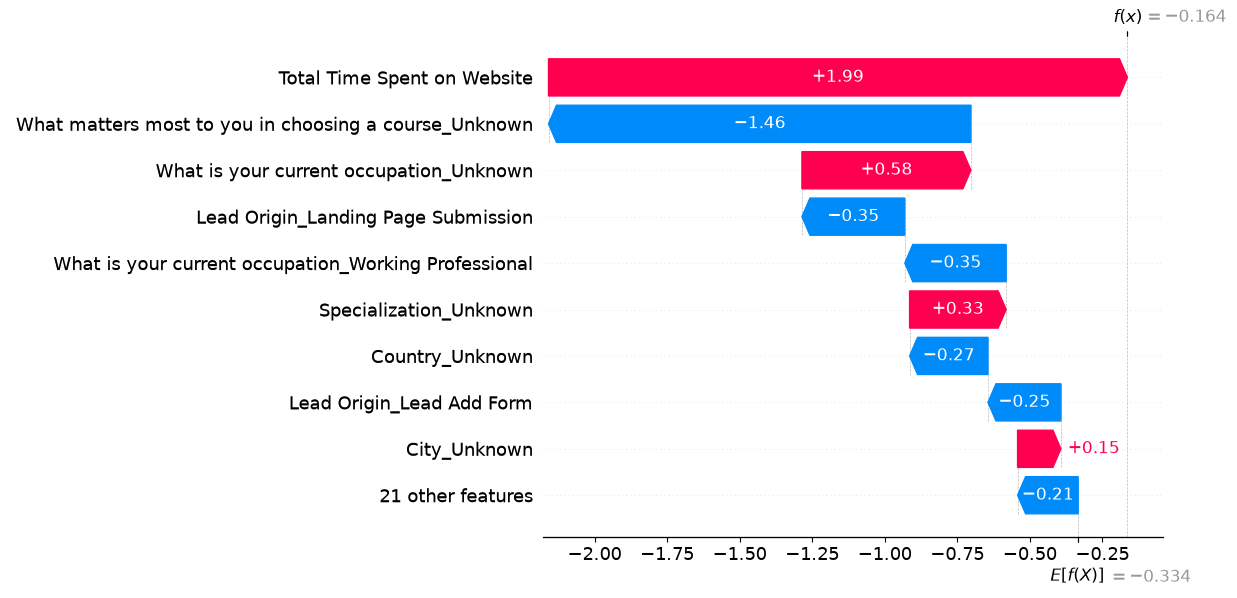

In [5]:
shap.plots._waterfall.waterfall_legacy(explainer.expected_value, shap_values[idx], X_test_scaled_df.iloc[idx])